# Data Visualization Assignment

This notebook demonstrates 5 distinct visualizations using Matplotlib with custom styling and proper labeling.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime, timedelta
import os

# Create imgs directory if it doesn't exist
os.makedirs('imgs', exist_ok=True)

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Line Plot: Temperature Trends Over Time

This line plot shows daily temperature variations over a 30-day period for two different cities. A line plot is ideal for displaying time series data and comparing trends across multiple locations. The plot clearly illustrates seasonal patterns and allows easy comparison of temperature fluctuations between the two cities.

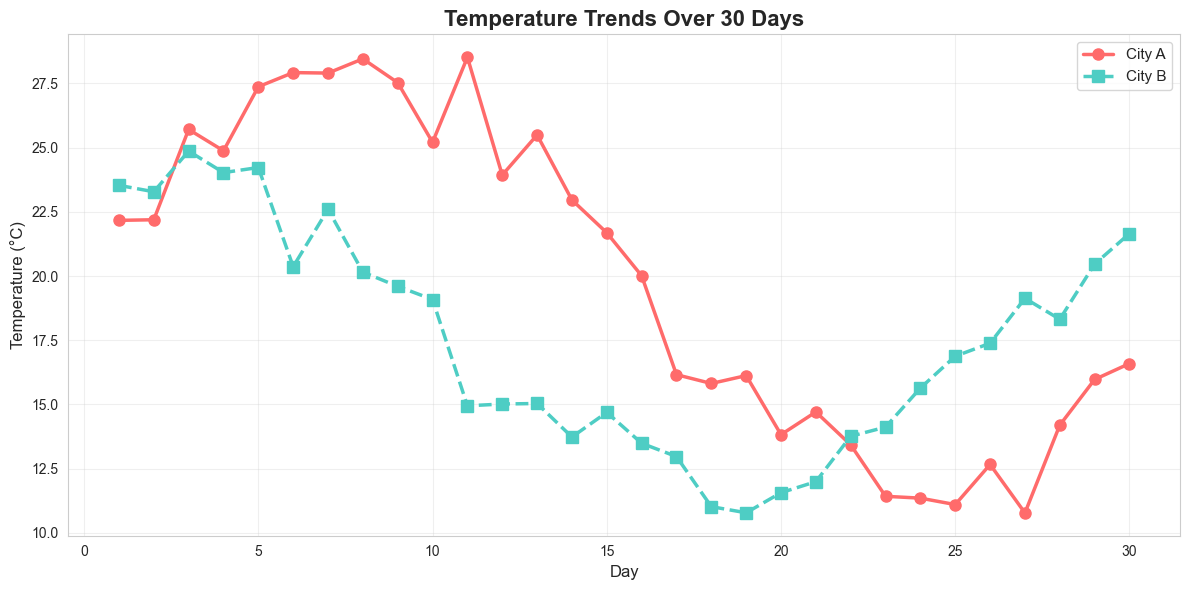

In [2]:
# Generate temperature data
days = np.arange(1, 31)
temp_city1 = 20 + 8 * np.sin(days / 5) + np.random.normal(0, 1, 30)
temp_city2 = 18 + 6 * np.sin(days / 5 + 1) + np.random.normal(0, 1, 30)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(days, temp_city1, marker='o', linestyle='-', linewidth=2.5, 
         label='City A', color='#FF6B6B', markersize=8)
plt.plot(days, temp_city2, marker='s', linestyle='--', linewidth=2.5, 
         label='City B', color='#4ECDC4', markersize=8)

plt.title('Temperature Trends Over 30 Days', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('imgs/line_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Bar Chart: Sales by Product Category

This bar chart displays sales revenue across five different product categories. Bar charts are excellent for comparing discrete values across categories. The color gradient and value labels make it easy to identify top-performing categories and compare relative sales performance at a glance.

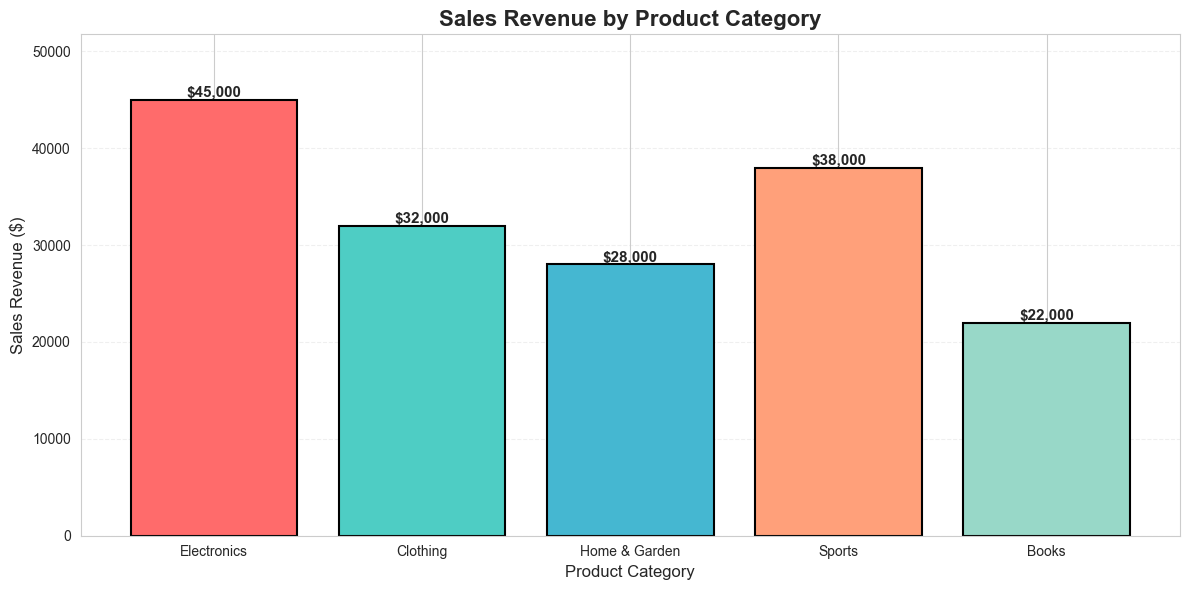

In [3]:
# Generate sales data
categories = ['Electronics', 'Clothing', 'Home & Garden', 'Sports', 'Books']
sales = [45000, 32000, 28000, 38000, 22000]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Create the plot
plt.figure(figsize=(12, 6))
bars = plt.bar(categories, sales, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, value in zip(bars, sales):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'${value:,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Sales Revenue by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Sales Revenue ($)', fontsize=12)
plt.ylim(0, max(sales) * 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.savefig('imgs/bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Histogram: Distribution of Student Test Scores

This histogram displays the distribution of test scores from 500 students. Histograms are ideal for understanding the shape and spread of numerical data. The visualization reveals that the scores follow a roughly normal distribution with a slight right skew, indicating most students scored between 65-85 points.

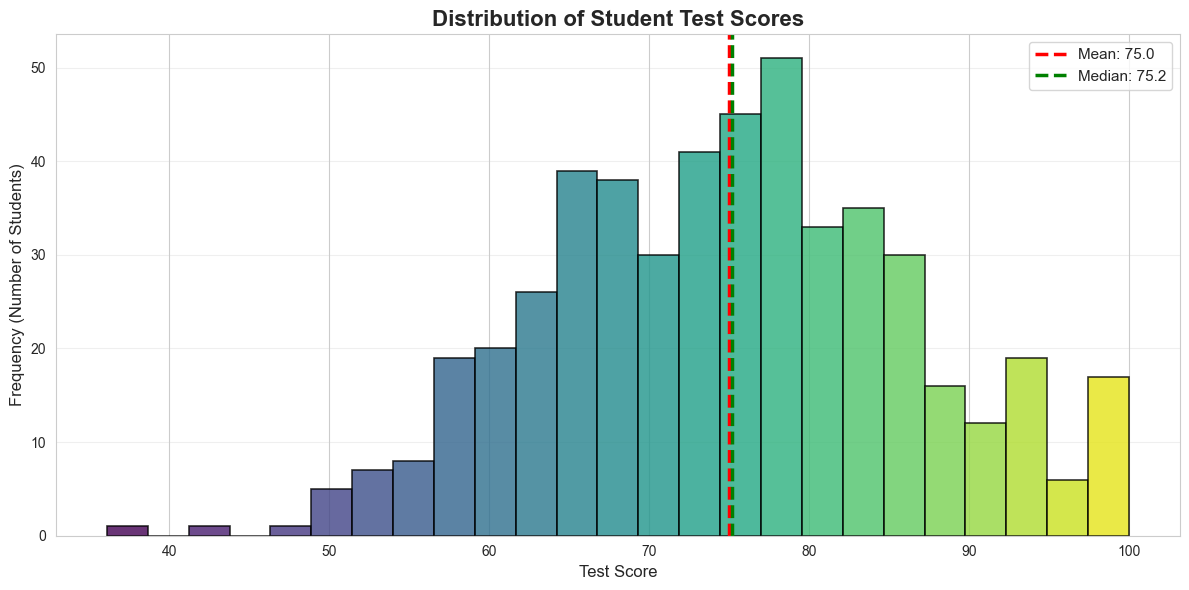

In [4]:
# Generate test scores
np.random.seed(42)
test_scores = np.random.normal(loc=75, scale=12, size=500)
test_scores = np.clip(test_scores, 0, 100)  # Ensure scores are between 0-100

# Create the plot
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(test_scores, bins=25, color='#45B7D1', 
                             edgecolor='black', alpha=0.8, linewidth=1.2)

# Add a gradient color to the histogram
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.viridis(i / len(patches)))

plt.title('Distribution of Student Test Scores', fontsize=16, fontweight='bold')
plt.xlabel('Test Score', fontsize=12)
plt.ylabel('Frequency (Number of Students)', fontsize=12)
plt.axvline(np.mean(test_scores), color='red', linestyle='--', linewidth=2.5, 
           label=f'Mean: {np.mean(test_scores):.1f}')
plt.axvline(np.median(test_scores), color='green', linestyle='--', linewidth=2.5, 
           label=f'Median: {np.median(test_scores):.1f}')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('imgs/histogram.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Scatter Plot: House Prices vs. Square Footage

This scatter plot demonstrates the relationship between house size and price across 100 properties. Scatter plots effectively reveal correlations and patterns in bivariate data. The positive linear relationship shown here indicates that larger houses tend to have higher prices, with a clear and strong positive correlation.

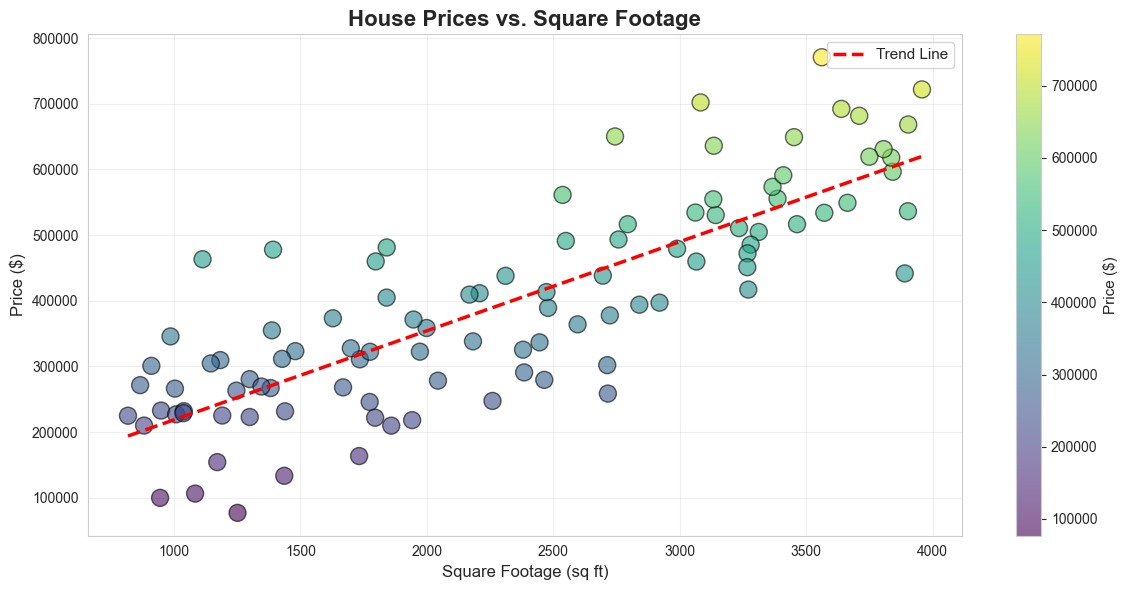

In [5]:
# Generate house data
np.random.seed(42)
square_footage = np.random.uniform(800, 4000, 100)
prices = 150 * square_footage + 50000 + np.random.normal(0, 100000, 100)

# Create the plot
plt.figure(figsize=(12, 6))
scatter = plt.scatter(square_footage, prices, s=150, alpha=0.6, 
                     c=prices, cmap='viridis', edgecolor='black', linewidth=1)

# Add a trend line
z = np.polyfit(square_footage, prices, 1)
p = np.poly1d(z)
x_trend = np.sort(square_footage)
plt.plot(x_trend, p(x_trend), "r--", linewidth=2.5, label='Trend Line')

plt.title('House Prices vs. Square Footage', fontsize=16, fontweight='bold')
plt.xlabel('Square Footage (sq ft)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(fontsize=11)
cbar = plt.colorbar(scatter)
cbar.set_label('Price ($)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('imgs/scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Pie Chart: Market Share Distribution

This pie chart illustrates the market share distribution among five major technology companies. Pie charts are perfect for showing compositional data and how different parts contribute to a whole. The exploded segments and percentage labels make it easy to compare the relative market positions of each company.

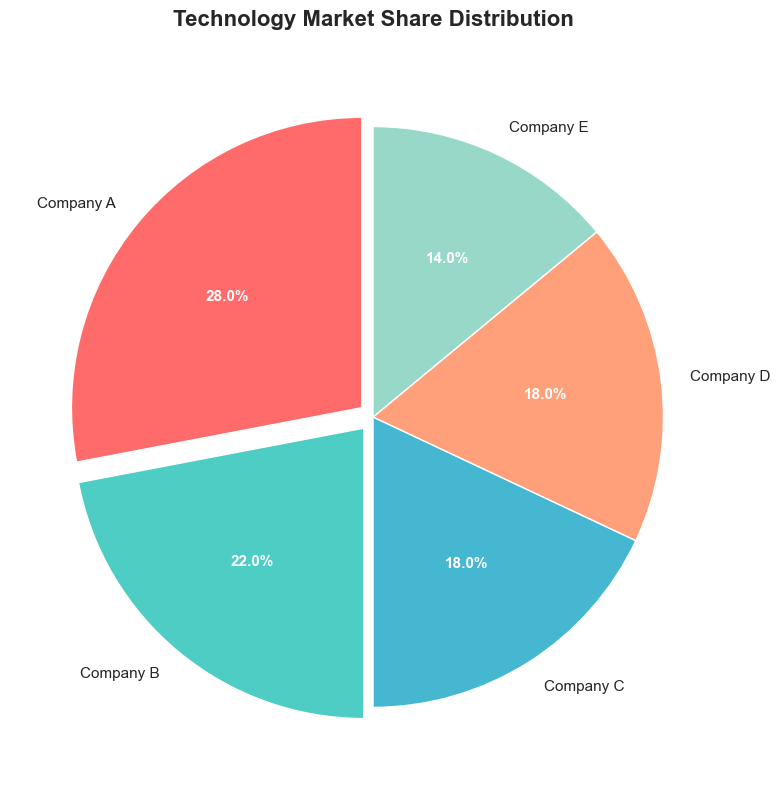

In [6]:
# Generate market share data
companies = ['Company A', 'Company B', 'Company C', 'Company D', 'Company E']
market_share = [28, 22, 18, 18, 14]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
explode = (0.05, 0.05, 0, 0, 0)

# Create the plot
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(market_share, labels=companies, autopct='%1.1f%%',
                                     colors=colors, explode=explode, startangle=90,
                                     textprops={'fontsize': 11})

# Customize the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

plt.title('Technology Market Share Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

plt.savefig('imgs/custom_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary

This notebook demonstrates 5 distinct visualization types:
1. **Line Plot**: Excellent for showing trends over time
2. **Bar Chart**: Perfect for comparing values across categories
3. **Histogram**: Ideal for understanding distributions
4. **Scatter Plot**: Great for revealing relationships between variables
5. **Pie Chart**: Useful for showing composition and proportions

All visualizations include:
- Descriptive titles
- Properly labeled axes
- Legends where appropriate
- Custom styling with colors, markers, and line styles
- High-resolution PNG exports in the `imgs` directory